In [4]:
import cv2
import copy
import random
import gc
import gym
import numpy as np
import torch
import ipywidgets as widgets
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from gym import spaces
from tqdm import tqdm
from collections import deque
from IPython import display
from IPython.display import clear_output
from matplotlib import animation

cv2.ocl.setUseOpenCL(False)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [5]:
class Replay_Buffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def store(self, state, action, new_state, reward, done):
        state = np.expand_dims(state, 0)
        new_state = np.expand_dims(new_state, 0)

        self.buffer.append([state, action, new_state, reward, done])

    def replay(self, batch_size):
        state, action, new_state, reward, done = zip(
            *random.sample(self.buffer, batch_size)
        )

        return np.concatenate(state), action, np.concatenate(new_state), reward, done

    def __len__(self):
        return len(self.buffer)

In [6]:
epsilon_S = 1.0
epsilon_E = 0.01
epsilon_decay = 30000

_epsilon = lambda frame: epsilon_E + (epsilon_S - epsilon_E)*np.exp(-frame/epsilon_decay)
# plt.plot([_epsilon(frame) for frame in range(1000000)]);

In [7]:
class NoopResetEnv(gym.Wrapper):
    def __init__(self, env, noop_max=30):
        gym.Wrapper.__init__(self, env)
        self.noop_max = noop_max
        self.override_num_noops = None
        self.noop_action = 0
        assert env.unwrapped.get_action_meanings()[0] == 'NOOP'

    def reset(self, **kwargs):
        self.env.reset(**kwargs)
        if self.override_num_noops is not None:
            noops = self.override_num_noops
        else:
            noops = self.unwrapped.np_random.integers(1, self.noop_max + 1) #pylint: disable=E1101
        assert noops > 0
        obs = None
        for _ in range(noops):
            obs, _, done, _, info = self.env.step(self.noop_action)
            if done:
                obs = self.env.reset(**kwargs)
        return obs, info

    def step(self, ac):
        return self.env.step(ac)

class FireResetEnv(gym.Wrapper):
    def __init__(self, env):
        gym.Wrapper.__init__(self, env)
        assert env.unwrapped.get_action_meanings()[1] == 'FIRE'
        assert len(env.unwrapped.get_action_meanings()) >= 3

    def reset(self, **kwargs):
        self.env.reset(**kwargs)
        obs, _, done, _, info = self.env.step(1)
        if done:
            self.env.reset(**kwargs)
        obs, _, done, _, info = self.env.step(2)
        if done:
            self.env.reset(**kwargs)
        return obs, info

    def step(self, ac):
        return self.env.step(ac)

class EpisodicLifeEnv(gym.Wrapper):
    def __init__(self, env):
        gym.Wrapper.__init__(self, env)
        self.lives = 0
        self.was_real_done  = True

    def step(self, action):
        obs, reward, done, truncated, info = self.env.step(action)
        self.was_real_done = done
        lives = self.env.unwrapped.ale.lives()
        if lives < self.lives and lives > 0:
            done = True
        self.lives = lives
        return obs, reward, done, truncated, info

    def reset(self, **kwargs):
        if self.was_real_done:
            obs, info = self.env.reset(**kwargs)
        else:
            # no-op step to advance from terminal/lost life state
            obs, _, _, _, info = self.env.step(0)
        self.lives = self.env.unwrapped.ale.lives()
        return obs, info

class MaxAndSkipEnv(gym.Wrapper):
    def __init__(self, env, skip=4):
        gym.Wrapper.__init__(self, env)
        # most recent raw observations (for max pooling across time steps)
        self._obs_buffer = np.zeros((2,)+env.observation_space.shape, dtype=np.uint8)
        self._skip       = skip

    def reset(self):
        return self.env.reset()

    def step(self, action):
        total_reward = 0.0
        done = None
        for i in range(self._skip):
            obs, reward, done, truncated, info = self.env.step(action)
            if i == self._skip - 2: self._obs_buffer[0] = obs
            if i == self._skip - 1: self._obs_buffer[1] = obs
            total_reward += reward
            if done:
                break

        max_frame = self._obs_buffer.max(axis=0)

        return max_frame, total_reward, done, truncated, info

    def reset(self, **kwargs):
        return self.env.reset(**kwargs)

class ClipRewardEnv(gym.RewardWrapper):
    def __init__(self, env):
        gym.RewardWrapper.__init__(self, env)

    def reward(self, reward):
        return np.sign(reward)

class WarpFrame(gym.ObservationWrapper):
    def __init__(self, env):
        gym.ObservationWrapper.__init__(self, env)
        self.width = 84
        self.height = 84
        self.observation_space = spaces.Box(low=0, high=255,
            shape=(self.height, self.width, 1), dtype=np.uint8)

    def observation(self, frame):
        frame = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
        frame = cv2.resize(frame, (self.width, self.height), interpolation=cv2.INTER_AREA)
        return frame[:, :, None]

class FrameStack(gym.Wrapper):
    def __init__(self, env, k):
        gym.Wrapper.__init__(self, env)
        self.k = k
        self.frames = deque([], maxlen=k)
        shp = env.observation_space.shape
        self.observation_space = spaces.Box(low=0, high=255, shape=(shp[0], shp[1], shp[2] * k), dtype=np.uint8)

    def reset(self):
        ob, info = self.env.reset()
        for _ in range(self.k):
            self.frames.append(ob)
        return self._get_ob(), info

    def step(self, action):
        ob, reward, done, info = self.env.step(action)
        self.frames.append(ob)
        return self._get_ob(), reward, done, info

    def _get_ob(self):
        assert len(self.frames) == self.k
        return LazyFrames(list(self.frames))

class ScaledFloatFrame(gym.ObservationWrapper):
    def __init__(self, env):
        gym.ObservationWrapper.__init__(self, env)

    def observation(self, observation):
        # careful! This undoes the memory optimization, use
        # with smaller replay buffers only.
        return np.array(observation).astype(np.float32) / 255.0

class LazyFrames(object):
    def __init__(self, frames):
        self._frames = frames
        self._out = None

    def _force(self):
        if self._out is None:
            self._out = np.concatenate(self._frames, axis=2)
            self._frames = None
        return self._out

    def __array__(self, dtype=None):
        out = self._force()
        if dtype is not None:
            out = out.astype(dtype)
        return out

    def __len__(self):
        return len(self._force())

    def __getitem__(self, i):
        return self._force()[i]

def make_atari(env_id, render_mode=None):
    env = gym.make(env_id, render_mode = render_mode)
    assert 'NoFrameskip' in env.spec.id
    env = NoopResetEnv(env, noop_max=30)
    env = MaxAndSkipEnv(env, skip=4)
    return env

def wrap_deepmind(env, episode_life=True, clip_rewards=True, frame_stack=False, scale=False):
    """Configure environment for DeepMind-style Atari.
    """
    if episode_life:
        env = EpisodicLifeEnv(env)
    if 'FIRE' in env.unwrapped.get_action_meanings():
        env = FireResetEnv(env)
    env = WarpFrame(env)
    if scale:
        env = ScaledFloatFrame(env)
    if clip_rewards:
        env = ClipRewardEnv(env)
    if frame_stack:
        env = FrameStack(env, 4)
    return env



class ImageToPyTorch(gym.ObservationWrapper):
    """
    Image shape to num_channels x weight x height
    """
    def __init__(self, env):
        super(ImageToPyTorch, self).__init__(env)
        old_shape = self.observation_space.shape
        self.observation_space = gym.spaces.Box(low=0.0, high=1.0, shape=(old_shape[-1], old_shape[0], old_shape[1]), dtype=np.uint8)

    def observation(self, observation):
        return np.swapaxes(observation, 2, 0)


def wrap_pytorch(env):
    return ImageToPyTorch(env)

In [12]:
env_id = "PongNoFrameskip-v4"
env    = make_atari(env_id, render_mode='rgb_array')
env    = wrap_deepmind(env)
env    = wrap_pytorch(env)

In [13]:
def compute_td_loss(batch_size, device):
    state, action, reward, next_state, done = replay_buffer.replay(batch_size)
    state      = torch.tensor(state).to(device)
    next_state = torch.tensor(np.array(next_state), requires_grad=False).to(device)
    action     = torch.LongTensor(action).to(device)
    reward     = torch.FloatTensor(reward).to(device)
    done       = torch.FloatTensor(done).to(device)

    q_values      = model(state)
    next_q_values = model(next_state)

    q_value          = q_values.gather(1, action.unsqueeze(1)).squeeze(1)
    next_q_value     = next_q_values.max(1)[0]
    expected_q_value = reward + gamma * next_q_value * (1 - done)

    loss = (q_value - expected_q_value.data).pow(2).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()

In [26]:
class CnnDQN(nn.Module):
    def __init__(self, input_shape, num_actions):
        super(CnnDQN, self).__init__()

        self.input_shape = input_shape
        self.num_actions = num_actions

        self.features = nn.Sequential(
            nn.Conv2d(input_shape[0], 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU()
        )

        self.fc = nn.Sequential(
            nn.Linear(self.feature_size(), 512),
            nn.ReLU(),
            nn.Linear(512, self.num_actions)
        )

    def forward(self, x):
        x = x.float()
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

    def feature_size(self):
        return self.features(torch.autograd.Variable(torch.zeros(1, *self.input_shape))).view(1, -1).size(1)

    def act(self, state, epsilon):
        with torch.no_grad():
            if random.random() > epsilon:
                state   = torch.FloatTensor(state).unsqueeze(0)
                state = state.to(device)
                q_value = self.forward(state)
                action  = q_value.max(1)[1].item()
            else:
                action = random.randrange(env.action_space.n)
        return action

In [9]:
import torch
print(torch.cuda.is_available())  # True면 정상
print(torch.cuda.get_device_name(0))  # GPU 이름 출력


True
NVIDIA GeForce GTX 1650 Ti with Max-Q Design


In [14]:
env.observation_space.shape

(1, 84, 84)

In [16]:
env.action_space.n


6

In [3]:
model = CnnDQN(env.observation_space.shape, env.action_space.n)

model = model.cuda()

optimizer = optim.Adam(model.parameters(), lr=0.00001)

replay_initial = 10000
replay_buffer = Replay_Buffer(100000)

NameError: name 'CnnDQN' is not defined

In [29]:
def plot(frame_idx, rewards, losses, game, game_data):
    clear_output(True)
    plt.figure(figsize=(20,5))
    plt.subplot(131)
    plt.title('frame %s. reward: %s' % (frame_idx, np.mean(rewards[-10:])))
    plt.plot(rewards)
    plt.subplot(132)
    plt.title('loss')
    plt.plot(losses)
    plt.subplot(133)
    plt.title(f'ep: {game_data[1]} max step: {game_data[2]}')
    plt.imshow(game)
    plt.show()

100%|██████████| 1400000/1400000 [4:46:48<00:00, 81.36it/s] 


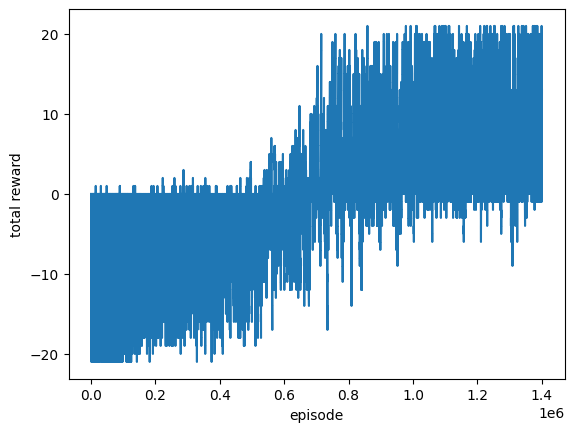

In [30]:
num_frames = 1400000
batch_size = 32
gamma      = 0.99

losses = []
all_rewards = []
episode_reward = 0
step = 0
ep = 0
max_steps = 0

state, _ = env.reset()
for frame_idx in tqdm(range(1, num_frames + 1)):

    epsilon = _epsilon(frame_idx)
    action = model.act(state, epsilon)

    next_state, reward, done, _, _ = env.step(action)
    replay_buffer.store(state, action, reward, next_state, float(done))

    state = next_state
    episode_reward += reward
    step += 1

    if done:
        state, _ = env.reset()
        all_rewards.append(episode_reward)
        episode_reward = 0
        max_steps = max(step, max_steps)
        step = 0
        ep += 1
        gc.collect()

    if len(replay_buffer) > replay_initial:
        loss = compute_td_loss(batch_size, device)
        losses.append(loss)

    all_rewards.append(episode_reward)
    if frame_idx % 10000 == 0:
        print("episode : {}, total reward : {}".format(ep, episode_reward))
        rgb_array = env.render()
        plot(frame_idx, all_rewards, losses, rgb_array, (step, ep, max_steps))

plt.xlabel('episode')
plt.ylabel('total reward')
plt.plot(range(len(all_rewards)), all_rewards)
plt.savefig('reward_plot.png', dpi=300, bbox_inches='tight')
plt.show()

In [1]:
ep

NameError: name 'ep' is not defined

In [36]:
def save_frames_as_gif(frames, path='./', filename='gym_animation2.gif'):

    #Mess with this to change frame size
    plt.figure(figsize=(frames[0].shape[1] / 72.0, frames[0].shape[0] / 72.0), dpi=72)

    patch = plt.imshow(frames[0])
    plt.axis('off')

    def animate(i):
        patch.set_data(frames[i])

    anim = animation.FuncAnimation(plt.gcf(), animate, frames = len(frames), interval=10)

    anim.save(path + filename, writer='imagemagick', fps=6)



state, _ = env.reset()
frames = []
for t in tqdm(range(1000)):
    #Render to frames buffer
    frames.append(env.render())
    action = model.act(state, epsilon)
    state, _, done, _, _ = env.step(action)
    if done:
        break

save_frames_as_gif(frames)
clear_output(wait=True)

In [41]:
state, _ = env.reset()
done = False
total_reward = 0

while not done:
    # 탐험 없이 항상 최적 행동 선택
    action = model.act(state, epsilon=0.0)
    next_state, reward, done, _, _ = env.step(action)
    state = next_state
    total_reward += reward
    env.render()  # 화면 출력 (옵션)
print('Total reward: {}'.format(total_reward))

Total reward: 20.0


In [37]:
gif_file = './gym_animation.gif'
file = open(gif_file, "rb")
image = file.read()
widgets.Image(
    value=image,
    format='png',
    width=300,
    height=400,
)

Image(value=b'GIF89a\xa0\x00\xd2\x00\x84\x00\x00\x90H\x11\xff\xff\xff\xec\xec\xec\xa5g:\xae~Z\xbd\x98|\\\xb9[\…

In [38]:
all_rewards

[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -1.0,
 -2.0,
 -2.0,
 -2.0,
 -2.0,
 -2.0,
 -2.0,
 -2.0,
 -2.0,
 -2.0,
 -2.0,
 -2.0,
 -2.0,
 -2.0,
 -2.0,
 -2.0,
 -2.0,
 -2.0,
 -2.0,
 -2.0,
 -2.0,
 -2.0,
 -2.0,
 -2.0,
 -2.0,
 -2.0,
 -2.0,
 -2.0,
 -2.0,
 -2.0,
 -2.0,
 -2.0,
 -2.0,
 -2.0,
 -2.0,
 -2.0,
 -3.0,
 -3.0,
 -3.0,
 -3.0,
 -3.0,
 -3.0,
 -3.0,
 -3.0,
 -3.0,
 -3.0,
 -3.0,
 -3.0,
 -3.0,
 -3.0,
 -3.0,
 -3.0,
 -3.0,
 -3.0,
 -3.0,
 -3.0,
 -3.0,
 -3.0,
 -3.0,
 -3.0,


In [33]:
torch.save(model, 'pingpong_dqn_model.pth')

In [34]:
torch.save(model.state_dict(), 'pingpong_dqn.pth')


In [16]:
import torch
model = torch.load('pingpong_dqn.pth', weights_only=False)
model.eval()

CnnDQN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(8, 8), stride=(4, 4))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
    (3): ReLU()
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (5): ReLU()
  )
  (fc): Sequential(
    (0): Linear(in_features=3136, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=6, bias=True)
  )
)

In [17]:
import torch
import numpy as np

# 모델 불러오기 (이미 불러온 경우 생략)
# model = CnnDQN(env.observation_space.shape, env.action_space.n)
# model.load_state_dict(torch.load('pingpong_dqn.pth'))
model.eval()

num_test_episodes = 100
all_rewards = []

for ep in range(num_test_episodes):
    obs = env.reset()
    if isinstance(obs, tuple):  # 최신 Gym 대응
        obs = obs[0]
    done = False
    episode_reward = 0
    while not done:
        # 상태 전처리 필요시 적용
        state = torch.tensor(np.array(obs), dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            q_values = model(state)
            action = q_values.argmax().item()
        next_obs, reward, done, *_ = env.step(action)
        obs = next_obs
        episode_reward += reward
    all_rewards.append(episode_reward)
    print(f"Episode {ep+1}: Total Reward = {episode_reward}")

# reward 그래프 그리기
import matplotlib.pyplot as plt
plt.plot(all_rewards)
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Evaluation Episode Rewards')
plt.show()


RuntimeError: Input type (torch.FloatTensor) and weight type (torch.cuda.FloatTensor) should be the same or input should be a MKLDNN tensor and weight is a dense tensor